# Data Preparation

## Current Problem

Our data has an imbalance of 94:6 (no claim : claim)

We want to have a similar amount of labels or classes that would help us identify claim and no claim. Having the majority as claim would not give enough data to our model to how a "no claim" policy holder would look like. 

Hence, we employ data-level techniques such as:

- SMOTE (Synthetic Minority Oversampling Technique)
    - Creates synthetic samples by interpolating between existing minority samples and their neighbors

- Random Undersampling

    - Removes majority class samples randomly

- Tomek Links
    - Remove pairs of examples from opposite classes that are nearest neighbors
    



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, precision_recall_curve, average_precision_score,
    roc_curve, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
import kagglehub
import os


In [2]:
path = kagglehub.dataset_download("litvinenko630/insurance-claims")

# List all files in the downloaded directory
files = os.listdir(path)
file_path = os.path.join(path, "Insurance claims data.csv")
df = pd.read_csv(file_path)



In [3]:
from helpers.preprocess import *

df_processed = preprocess_data(df)

print(f"Processed shape: {df_processed.shape}")
print(f"\nFeature types after processing:")
print(df_processed.dtypes.value_counts())

Dropping high-cardinality columns: ['region_code']
  (Unique values: [22])
Processed shape: (58592, 65)

Feature types after processing:
bool       48
int64      10
float64     7
Name: count, dtype: int64


In [4]:
# Separate features and target
X = df_processed.drop('claim_status', axis=1)
y = df_processed['claim_status']

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts())

Training set: 46873 samples
Test set: 11719 samples

Training class distribution:
claim_status
0    43875
1     2998
Name: count, dtype: int64


## SMOTE

1. For each minority sample, find its k nearest neighbors (default k=5)
2. Randomly select one of those neighbors
3. Create a new synthetic sample along the line connecting them

Formula: `new_sample = original + random(0,1) × (neighbor - original)` 

This creates realistic variations that help the model generalize better.

### Also has some Variants
#### BorderlineSMOTE
Only generates synthetic samples for minority instances that are **near the decision boundary** (close to majority samples). This focuses on the hard-to-classify cases.

#### ADASYN (Adaptive Synthetic Sampling)
Generates **more synthetic samples** for minority instances that are harder to classify (surrounded by majority samples). It's adaptive to the local density.

Our goal here is to identify which sampling technique to use.

In [5]:
# Scale features to standardize them
# mean = 0, sigma = 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
borderSmote = BorderlineSMOTE(random_state=0) # Make more of minority samples most similar (euclid) to majority
X_resampled, y_resampled  = borderSmote.fit_resample(X_train_scaled, y_train)

result = []
modelSmote = LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced')
modelSmote.fit(X_resampled, y_resampled)

# model is tested on the same test set
y_pred = modelSmote.predict(X_test)
y_proba = modelSmote.predict_proba(X_test)[:, 1]
        
        # Calculate metrics (for the minority/positive class)
metrics = {
        'Train Samples': len(y_resampled),
        'Minority Samples': sum(y_resampled == 1),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'AUC-PR': average_precision_score(y_test, y_proba)
    }

print(f" Done - F1: {metrics['F1 Score']:.4f}, AUC-PR: {metrics['AUC-PR']:.4f}")
print(f"\nAccuracy: {(y_pred == y_test).mean():.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Claim', 'Claim']))


 Done - F1: 0.0213, AUC-PR: 0.0679

Accuracy: 0.9294

Classification Report:
              precision    recall  f1-score   support

    No Claim       0.94      0.99      0.96     10969
       Claim       0.09      0.01      0.02       750

    accuracy                           0.93     11719
   macro avg       0.52      0.50      0.49     11719
weighted avg       0.88      0.93      0.90     11719



In [7]:
smote       = SMOTE(random_state=0)           # Make more of minority samples at random
X_resampled, y_resampled    = smote.fit_resample(X_train_scaled, y_train)

result = []
modelSmote = LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced')
modelSmote.fit(X_resampled, y_resampled)

# model is tested on the same test set
y_pred = modelSmote.predict(X_test)
y_proba = modelSmote.predict_proba(X_test)[:, 1]
        
        # Calculate metrics (for the minority/positive class)
metrics = {
        'Train Samples': len(X_resampled),
        'Minority Samples': sum(y_resampled == 1),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'AUC-PR': average_precision_score(y_test, y_proba)
    }

print(f" Done - F1: {metrics['F1 Score']:.4f}, AUC-PR: {metrics['AUC-PR']:.4f}")
print(f"\nAccuracy: {(y_pred == y_test).mean():.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Claim', 'Claim']))


 Done - F1: 0.0000, AUC-PR: 0.0695

Accuracy: 0.9360

Classification Report:
              precision    recall  f1-score   support

    No Claim       0.94      1.00      0.97     10969
       Claim       0.00      0.00      0.00       750

    accuracy                           0.94     11719
   macro avg       0.47      0.50      0.48     11719
weighted avg       0.88      0.94      0.91     11719



In [8]:
adasyn      = ADASYN(random_state=0)          # similar to border but more minority
X_resampled, y_resampled    = adasyn.fit_resample(X_train_scaled, y_train)

result = []
modelSmote = LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced')
modelSmote.fit(X_resampled, y_resampled)

# model is tested on the same test set
y_pred = modelSmote.predict(X_test)
y_proba = modelSmote.predict_proba(X_test)[:, 1]
        
        # Calculate metrics (for the minority/positive class)
metrics = {
        'Train Samples': len(X_resampled),
        'Minority Samples': sum(y_resampled == 1),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'AUC-PR': average_precision_score(y_test, y_proba)
    }

print(f" Done - F1: {metrics['F1 Score']:.4f}, AUC-PR: {metrics['AUC-PR']:.4f}")
print(f"\nAccuracy: {(y_pred == y_test).mean():.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Claim', 'Claim']))


 Done - F1: 0.0265, AUC-PR: 0.0692

Accuracy: 0.9247

Classification Report:
              precision    recall  f1-score   support

    No Claim       0.94      0.99      0.96     10969
       Claim       0.08      0.02      0.03       750

    accuracy                           0.92     11719
   macro avg       0.51      0.50      0.49     11719
weighted avg       0.88      0.92      0.90     11719



In [9]:
smoteTomek  = SMOTETomek(random_state=0)
X_resampled, y_resampled    = smoteTomek.fit_resample(X_train_scaled, y_train)

result = []
modelSmote = LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced')
modelSmote.fit(X_resampled, y_resampled)

# model is tested on the same test set
y_pred = modelSmote.predict(X_test)
y_proba = modelSmote.predict_proba(X_test)[:, 1]
        
        # Calculate metrics (for the minority/positive class)
metrics = {
        'Train Samples': len(X_resampled),
        'Minority Samples': sum(y_resampled == 1),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'AUC-PR': average_precision_score(y_test, y_proba)
    }

print(f" Done - F1: {metrics['F1 Score']:.4f}, AUC-PR: {metrics['AUC-PR']:.4f}")
print(f"\nAccuracy: {(y_pred == y_test).mean():.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Claim', 'Claim']))


 Done - F1: 0.0000, AUC-PR: 0.0695

Accuracy: 0.9360

Classification Report:
              precision    recall  f1-score   support

    No Claim       0.94      1.00      0.97     10969
       Claim       0.00      0.00      0.00       750

    accuracy                           0.94     11719
   macro avg       0.47      0.50      0.48     11719
weighted avg       0.88      0.94      0.91     11719



Training: Baseline (No Resampling)...
 Done - F1: 0.1527, AUC-PR: 0.0917
Training: SMOTE...
 Done - F1: 0.1518, AUC-PR: 0.0908
Training: BorderlineSMOTE...
 Done - F1: 0.1508, AUC-PR: 0.0899
Training: ADASYN...
 Done - F1: 0.1525, AUC-PR: 0.0910
Training: SMOTE + Tomek...
 Done - F1: 0.1518, AUC-PR: 0.0908

RESAMPLING TECHNIQUES COMPARISON
               Technique Train Samples Minority Samples Precision Recall F1 Score AUC-ROC AUC-PR
Baseline (No Resampling)        46,873            2,998    0.0871 0.6160   0.1527  0.6203 0.0917
                  ADASYN        88,012           44,137    0.0871 0.6120   0.1525  0.6205 0.0910
           SMOTE + Tomek        85,636           42,818    0.0868 0.6053   0.1518  0.6190 0.0908
                   SMOTE        87,750           43,875    0.0868 0.6053   0.1518  0.6190 0.0908
         BorderlineSMOTE        87,750           43,875    0.0870 0.5653   0.1508  0.6152 0.0899

Best by F1 Score: Baseline (No Resampling) (F1: 0.1527)


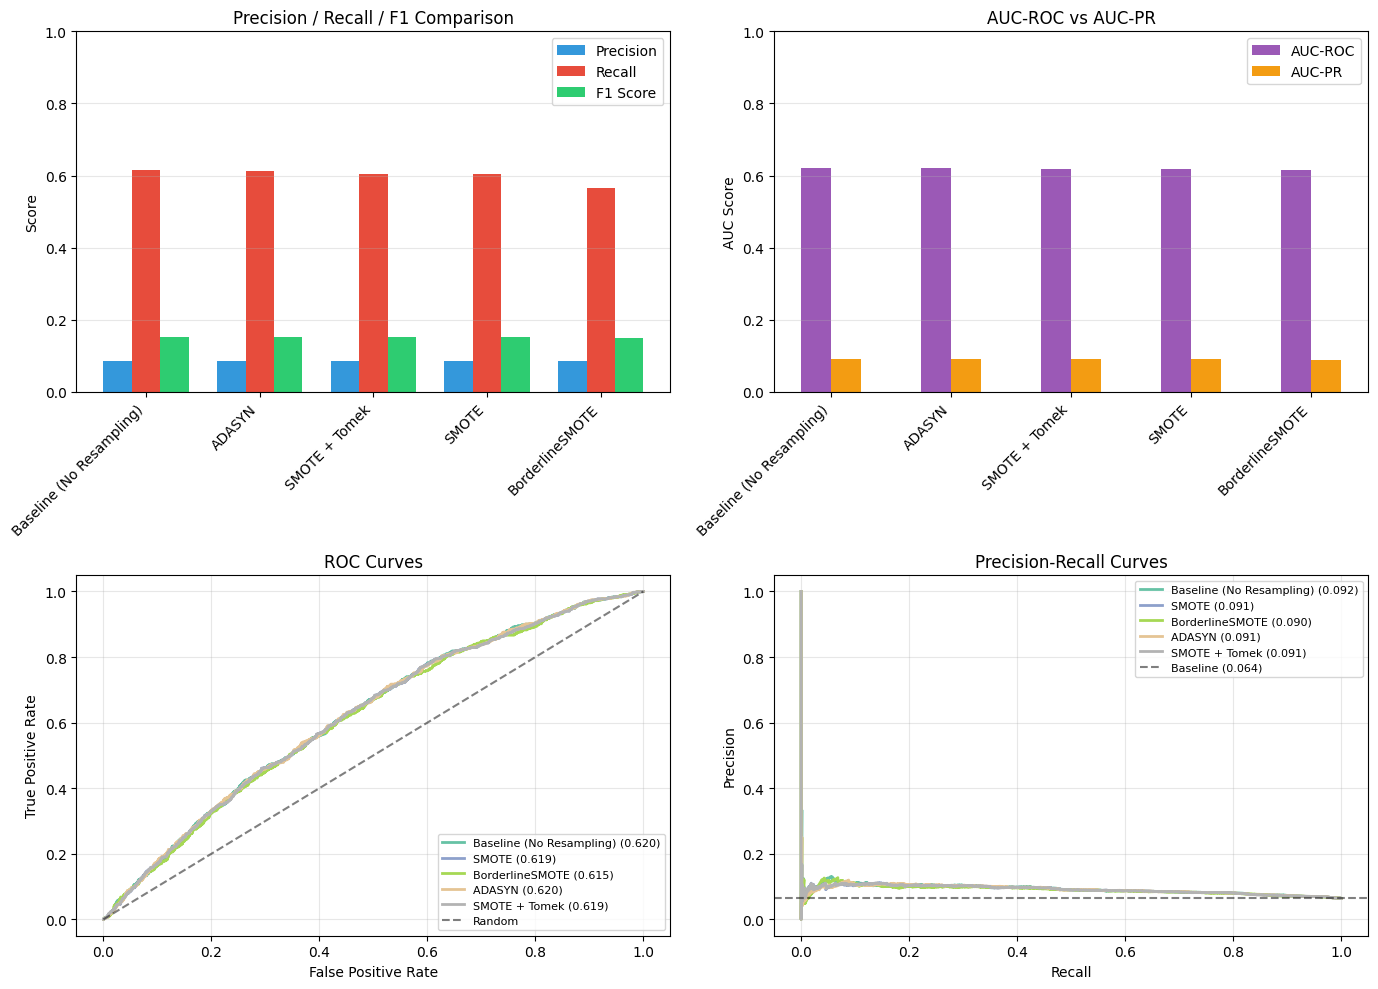


 Plot saved as 'resampling_comparison.png'


In [12]:
from helpers.compare_resampling import *
results_df, detailed_results = compare_resampling_techniques(X_train_scaled, y_train, X_test_scaled, y_test )
display_comparison(results_df)
plot_comparison(results_df, detailed_results, y_test)